# Sales Data Analysis

## 1. Import Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

## 2. Load Dataset

In [2]:
sales_df = pd.read_csv("data/sales_data.csv")

## 3. Initial Data Exploration

### 3.1 Dataset Dimensions

In [3]:
rows, columns = sales_df.shape

print(f"Rows: {rows}")
print(f"Columns: {columns}")

Rows: 113036
Columns: 18


### 3.2 Data Types

In [4]:
sales_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 113036 entries, 0 to 113035
Data columns (total 18 columns):
 #   Column            Non-Null Count   Dtype
---  ------            --------------   -----
 0   Date              113036 non-null  str  
 1   Day               113036 non-null  int64
 2   Month             113036 non-null  str  
 3   Year              113036 non-null  int64
 4   Customer_Age      113036 non-null  int64
 5   Age_Group         113036 non-null  str  
 6   Customer_Gender   113036 non-null  str  
 7   Country           113036 non-null  str  
 8   State             113036 non-null  str  
 9   Product_Category  113036 non-null  str  
 10  Sub_Category      113036 non-null  str  
 11  Product           113036 non-null  str  
 12  Order_Quantity    113036 non-null  int64
 13  Unit_Cost         113036 non-null  int64
 14  Unit_Price        113036 non-null  int64
 15  Profit            113036 non-null  int64
 16  Cost              113036 non-null  int64
 17  Revenue           113

### 3.3 Missing Values

In [5]:
sales_df.isnull().sum()

Date                0
Day                 0
Month               0
Year                0
Customer_Age        0
Age_Group           0
Customer_Gender     0
Country             0
State               0
Product_Category    0
Sub_Category        0
Product             0
Order_Quantity      0
Unit_Cost           0
Unit_Price          0
Profit              0
Cost                0
Revenue             0
dtype: int64

### 3.4 Duplicate Records

In [6]:
sales_df.duplicated().sum()

np.int64(1000)

### 3.5 Numerical Summary

In [7]:
sales_df.describe().T

,count,mean,std,min,25%,50%,75%,max
Day,113036.0,15.665753,8.781567,1.0,8.0,16.0,23.0,31.0
Year,113036.0,2014.401739,1.272510,2011.0,2013.0,2014.0,2016.0,2016.0
Customer_Age,113036.0,35.919212,11.021936,17.0,28.0,35.0,43.0,87.0
Order_Quantity,113036.0,11.901660,9.561857,1.0,2.0,10.0,20.0,32.0
Unit_Cost,113036.0,267.296366,549.835483,1.0,2.0,9.0,42.0,2171.0
Unit_Price,113036.0,452.938427,922.071219,2.0,5.0,24.0,70.0,3578.0
Profit,113036.0,285.051665,453.887443,-30.0,29.0,101.0,358.0,15096.0
Cost,113036.0,469.318695,884.866118,1.0,28.0,108.0,432.0,42978.0
Revenue,113036.0,754.370360,1309.094674,2.0,63.0,223.0,800.0,58074.0


### 3.6 Numerical Ranges

In [8]:
sales_df.describe().T[['min', 'max']]

,min,max
Day,1.0,31.0
Year,2011.0,2016.0
Customer_Age,17.0,87.0
Order_Quantity,1.0,32.0
Unit_Cost,1.0,2171.0
Unit_Price,2.0,3578.0
Profit,-30.0,15096.0
Cost,1.0,42978.0
Revenue,2.0,58074.0


### 3.7 Unique Categories

In [9]:
print(f'Count of Unique Product - {sales_df['Product'].nunique()}' )

sales_df['Product'].unique()

sales_df['Product'].value_counts()

Count of Unique Product - 130


Product
Water Bottle - 30 oz.      10794
Patch Kit/8 Patches        10416
Mountain Tire Tube          6816
AWC Logo Cap                4358
Sport-100 Helmet, Red       4220
                           ...  
Touring-3000 Blue, 50         58
Mountain-100 Silver, 42       54
Mountain-500 Silver, 48       40
Road-650 Red, 52              32
Mountain-500 Black, 52        22
Name: count, Length: 130, dtype: int64

In [10]:
print(f'Count of unique Product_Category - {sales_df['Product_Category'].nunique()}')

sales_df['Product_Category'].unique()

sales_df['Product_Category'].value_counts()

Count of unique Product_Category - 3


Product_Category
Accessories    70120
Bikes          25982
Clothing       16934
Name: count, dtype: int64

In [11]:
print(f'Count of unique Sub_Category - {sales_df['Sub_Category'].nunique()}')

sales_df['Sub_Category'].unique()

sales_df['Sub_Category'].value_counts()

Count of unique Sub_Category - 17


Sub_Category
Tires and Tubes      33870
Bottles and Cages    15876
Road Bikes           13430
Helmets              12158
Mountain Bikes        8854
Jerseys               6010
Caps                  4358
Fenders               4032
Touring Bikes         3698
Gloves                2686
Cleaners              1802
Shorts                1794
Hydration Packs       1334
Socks                 1122
Vests                  964
Bike Racks             592
Bike Stands            456
Name: count, dtype: int64

## 4. Data Cleaning

### 4.1 Remove Duplicate

In [12]:
print(f'Number of duplicate rows: {sales_df.duplicated().sum()}')

duplicate_rows = sales_df[sales_df.duplicated(keep=False)]

duplicate_rows.sort_values(by=list(sales_df.columns)).head(20)

sales_df = sales_df.drop_duplicates(keep='first')

sales_df = sales_df.reset_index(drop=True)

print(f'Remaining duplicates: {sales_df.duplicated().sum()}')



Number of duplicate rows: 1000
Remaining duplicates: 0


### 4.2 Change datatype of the Date column

In [13]:
sales_df['Date'] = pd.to_datetime(sales_df['Date'], 
                                  format='%Y-%m-%d', 
                                  errors='coerce')

print(sales_df['Date'].dtype)

sales_df['Date'].isna().sum()


datetime64[us]


np.int64(0)

### 4.3 Check Validity of the Numerical Value

#### 4.3.1 Numerical Columns

In [14]:
numerical_col = sales_df.select_dtypes(include='number').columns
print('Numerical columns: ')
print(numerical_col)

Numerical columns: 
Index(['Day', 'Year', 'Customer_Age', 'Order_Quantity', 'Unit_Cost',
       'Unit_Price', 'Profit', 'Cost', 'Revenue'],
      dtype='str')


#### 4.3.2 Check For Impossible Value

In [15]:
sales_df[numerical_col].describe().T

,count,mean,std,min,25%,50%,75%,max
Day,112036.0,15.665607,8.781485,1.0,8.0,16.0,23.0,31.0
Year,112036.0,2014.400925,1.273327,2011.0,2013.0,2014.0,2016.0,2016.0
Customer_Age,112036.0,35.919508,11.016543,17.0,28.0,35.0,43.0,87.0
Order_Quantity,112036.0,11.904254,9.564877,1.0,2.0,10.0,20.0,32.0
Unit_Cost,112036.0,267.819603,550.218722,1.0,2.0,9.0,42.0,2171.0
Unit_Price,112036.0,453.850628,922.751848,2.0,5.0,25.0,70.0,3578.0
Profit,112036.0,286.035194,454.852634,-30.0,29.0,103.0,360.0,15096.0
Cost,112036.0,471.103333,886.971635,1.0,28.0,112.0,442.0,42978.0
Revenue,112036.0,757.138527,1312.061623,2.0,64.0,226.0,806.0,58074.0


#### 4.3.3 Investigate Negative Profit

In [16]:
profit_check = sales_df['Revenue'] - sales_df['Cost']

(sales_df['Profit'] != profit_check).sum()

np.int64(0)

### 4.4 Check Categorical Columns

#### 4.4.1 Categorical Columns

In [17]:
categorical_col = sales_df.select_dtypes(include=['object', 'str']).columns

print("categorical Colums:")
print(categorical_col)

categorical Colums:
Index(['Month', 'Age_Group', 'Customer_Gender', 'Country', 'State',
       'Product_Category', 'Sub_Category', 'Product'],
      dtype='str')


#### 4.4.2 Unique Values

In [18]:
for column in categorical_col:
    print(f'\n---{column}---')
    print(f'Unique Value Count = {sales_df[column].nunique()}')
    print(f'Unique Values = {sales_df[column].unique()}')
    print(f'Unique Value Frequenies :\n{sales_df[column].value_counts()}')
    print()


---Month---
Unique Value Count = 12


Unique Values = <StringArray>
[ 'November',     'March',       'May',  'February',      'July',    'August',
 'September',   'January',  'December',      'June',   'October',     'April']
Length: 12, dtype: str
Unique Value Frequenies :
Month
June         11127
December     11109
May          11019
April        10090
March         9591
January       9192
February      8956
October       8678
November      8646
August        8128
September     8100
July          7400
Name: count, dtype: int64


---Age_Group---
Unique Value Count = 4
Unique Values = <StringArray>
['Youth (<25)', 'Adults (35-64)', 'Young Adults (25-34)', 'Seniors (64+)']
Length: 4, dtype: str
Unique Value Frequenies :
Age_Group
Adults (35-64)          55358
Young Adults (25-34)    38299
Youth (<25)             17660
Seniors (64+)             719
Name: count, dtype: int64


---Customer_Gender---
Unique Value Count = 2
Unique Values = <StringArray>
['M', 'F']
Length: 2, dtype: str
Unique Value Frequenies :
Customer_Gender
M

# 5. Feature Engineering

## 5.1 Calculate Profit Margin

In [19]:
sales_df['Profit_margin'] = (sales_df['Profit'] / sales_df['Revenue']) * 100

sales_df[[
    'Revenue',
    'Profit',
    'Profit_margin'
]].head()

,Revenue,Profit,Profit_margin
0,950,590,62.105263
1,950,590,62.105263
2,2401,1366,56.892961
3,2088,1188,56.896552
4,418,238,56.937799


## 5.2 Extract Day Of The Week

In [20]:
sales_df['Day_of_week'] = sales_df['Date'].dt.day_name()

sales_df[[
    'Date',
    'Day_of_week'
]].head()

,Date,Day_of_week
0,2013-11-26,Tuesday
1,2015-11-26,Thursday
2,2014-03-23,Sunday
3,2016-03-23,Wednesday
4,2014-05-15,Thursday


# 6. Business Analaysis

## 6.1 Total Revenue by Product

In [21]:
revenue_by_product = sales_df.groupby('Product')['Revenue'].sum()
revenue_by_product = revenue_by_product.sort_values(ascending=False).reset_index()
revenue_by_product

,Product,Revenue
0,"Road-150 Red, 62",3810023
1,"Mountain-200 Black, 38",3345501
2,"Road-150 Red, 52",3152610
3,"Road-150 Red, 56",3142811
4,"Mountain-200 Silver, 42",3070174
...,...,...
125,"Mountain-500 Silver, 44",49638
126,"Touring-3000 Blue, 50",45694
127,"Road-650 Red, 52",34669
128,"Mountain-500 Silver, 48",25794


## 6.2 Total Quantity Sold by Product

In [22]:
quantity_by_product = sales_df.groupby('Product')['Order_Quantity'].sum()
quantity_by_product = quantity_by_product.sort_values(ascending=False).reset_index()
quantity_by_product

,Product,Order_Quantity
0,Water Bottle - 30 oz.,162051
1,Patch Kit/8 Patches,155310
2,Mountain Tire Tube,100915
3,AWC Logo Cap,67316
4,"Sport-100 Helmet, Red",63652
...,...,...
125,"Mountain-100 Black, 42",72
126,"Touring-3000 Blue, 50",70
127,"Mountain-500 Silver, 48",52
128,"Road-650 Red, 52",52


## 6.3 Compare Revenue and Quantity

In [23]:
product_summary = sales_df.groupby('Product').agg(
    Total_Quantity=('Order_Quantity', 'sum'),
    Total_Revenue=('Revenue', 'sum')
)

product_summary = product_summary.sort_values(by='Total_Revenue', ascending=False)
product_summary

,Total_Quantity,Total_Revenue
Product,,
"Road-150 Red, 62",1185,3810023
"Mountain-200 Black, 38",1632,3345501
"Road-150 Red, 52",971,3152610
"Road-150 Red, 56",985,3142811
"Mountain-200 Silver, 42",1456,3070174
...,...,...
"Mountain-500 Silver, 44",96,49638
"Touring-3000 Blue, 50",70,45694
"Road-650 Red, 52",52,34669


## 6.4 Revenue, Quantity, and Profit by Category

In [24]:
category_summary = sales_df.groupby('Product_Category').agg(
    Total_Revenue=('Revenue', 'sum'),
    Total_Quantity=('Order_Quantity', 'sum'),
    Total_Profit=('Profit', 'sum')
)

category_summary = category_summary.sort_values(by='Total_Revenue', ascending=False)
category_summary

,Total_Revenue,Total_Quantity,Total_Profit
Product_Category,,,
Bikes,61434484,36201,20399726
Accessories,15022766,1042791,8807194
Clothing,8369522,254713,2839319


## 6.5 Profitabilty Analysis

In [26]:
profit_by_product = sales_df.groupby('Product')['Profit'].sum()
profit_by_product = profit_by_product.sort_values(ascending=False).reset_index()

margin_by_product = sales_df.groupby('Product')['Profit_margin'].mean()
margin_by_product = margin_by_product.sort_values(ascending=False)

profitability_summary = sales_df.groupby('Product').agg(
    Total_Revenue=('Revenue', 'sum'),
    Total_Profit=('Profit', 'sum'),
    Avg_Profit_Margin=('Profit_margin', 'mean')
)

profitability_summary_by_profit = profitability_summary.sort_values(by='Total_Profit', ascending=False)
profitability_summary_by_margin = profitability_summary.sort_values(by='Avg_Profit_Margin', ascending=False)

print("Sorted by total profit:")
print(profitability_summary_by_profit.head(10))

print("\nSorted by average profit margin:")
print(profitability_summary_by_margin.head(10))

Sorted by total profit:
                         Total_Revenue  Total_Profit  Avg_Profit_Margin
Product                                                                
Mountain-200 Black, 38         3345501       1302237          38.573512
Road-150 Red, 62               3810023       1237388          31.900911
Mountain-200 Silver, 42        3070174       1226878          39.611838
Sport-100 Helmet, Red          2018651       1191175          58.656103
Mountain-200 Silver, 38        3011267       1155311          38.051256
Sport-100 Helmet, Black        1947731       1140795          58.249036
Mountain-200 Black, 46         2756837       1075401          38.805113
Sport-100 Helmet, Blue         1773816       1047701          58.748994
Road-150 Red, 52               3152610       1044569          32.445643
Mountain-200 Black, 42         2630865       1032061          38.765678

Sorted by average profit margin:
                            Total_Revenue  Total_Profit  Avg_Profit_Margin
Pro

## 6.6 Time-Based Analysis

In [27]:
revenue_by_year = sales_df.groupby('Year')['Revenue'].sum().reset_index()
revenue_by_year = revenue_by_year.sort_values(by='Year')
revenue_by_year

,Year,Revenue
0,2011,8951966
1,2012,9133795
2,2013,15117327
3,2014,14040192
4,2015,19945703
5,2016,17637789


In [28]:
revenue_by_month = sales_df.groupby('Month')['Revenue'].sum().reset_index()
revenue_by_month = revenue_by_month.sort_values(by='Revenue', ascending=False)
revenue_by_month

,Month,Revenue
2,December,9046323
6,June,8978817
8,May,8789287
0,April,7568874
7,March,7306140
4,January,6961166
3,February,6805834
9,November,6206951
10,October,5956276
11,September,5822197


In [32]:
daily_revenue = sales_df.groupby('Day_of_week')['Revenue'].sum().reset_index()
daily_revenue.columns = ['Date', 'Daily_Revenue']
daily_revenue

,Date,Daily_Revenue
0,Friday,12079275
1,Monday,12007965
2,Saturday,12488578
3,Sunday,12268543
4,Thursday,11831242
5,Tuesday,11934925
6,Wednesday,12216244


## 6.7 Customer Analysis

### 6.7.1 Revenue by Age Group

In [33]:
revenue_by_age_group = sales_df.groupby('Age_Group')['Revenue'].sum()
revenue_by_age_group = revenue_by_age_group.sort_values(ascending=False)
revenue_by_age_group

Age_Group
Adults (35-64)          42367181
Young Adults (25-34)    30467032
Youth (<25)             11685489
Seniors (64+)             307070
Name: Revenue, dtype: int64

### 6.7.2 Revenue by Gender

In [34]:
revenue_by_gender = sales_df.groupby('Customer_Gender')['Revenue'].sum()
revenue_by_gender = revenue_by_gender.sort_values(ascending=False)
revenue_by_gender

Customer_Gender
M    43132083
F    41694689
Name: Revenue, dtype: int64

### 6.7.3 Revenue by Country

In [35]:
revenue_by_country = sales_df.groupby('Country')['Revenue'].sum()
revenue_by_country = revenue_by_country.sort_values(ascending=False)
revenue_by_country

Country
United States     27777098
Australia         21196395
United Kingdom    10575628
Germany            8956724
France             8414745
Canada             7906182
Name: Revenue, dtype: int64

# 7. Visualization

## 7.1 Revenue by Category

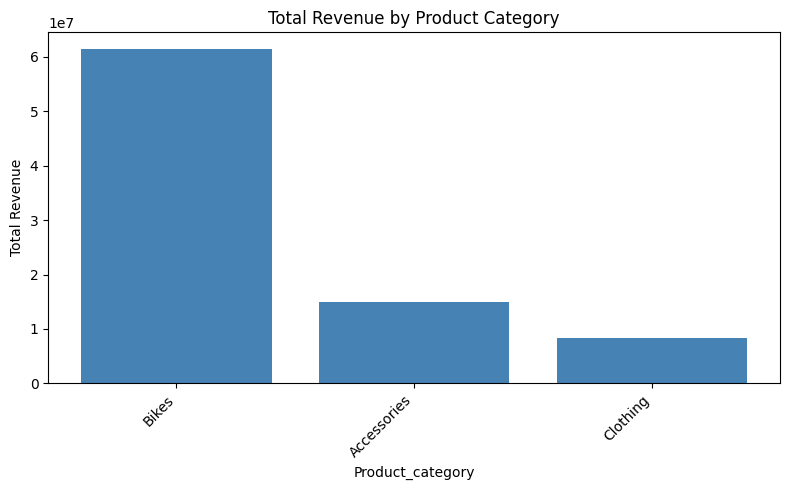

In [ ]:
plt.figure(figsize=(8, 5))
plt.bar(category_summary.index, category_summary['Total_Revenue'], color='steelblue')
plt.title('Total Revenue by Product Category')
plt.xlabel('Product_category')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 7.2 Profit by Category

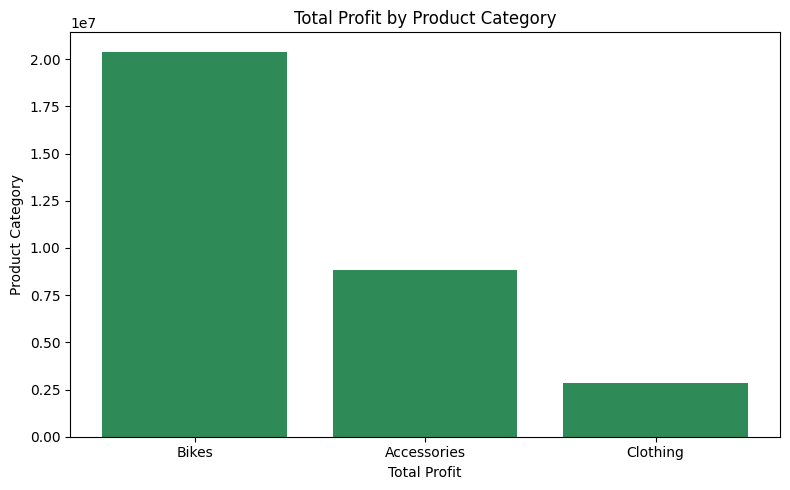

In [ ]:
plt.figure(figsize=(8, 5))
plt.bar(category_summary.index, category_summary['Total_Profit'], color='seagreen')
plt.title('Total Profit by Product Category')
plt.xlabel('Total Profit')
plt.ylabel('Product Category')
plt.tight_layout()
plt.show()